In [2]:
from pathlib import Path

base = Path("/kaggle/input")
print("Folders inside /kaggle/input:\n")

for p in base.iterdir():
    print("-", p)

Folders inside /kaggle/input:

- /kaggle/input/datasets


In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("pypiahmad/ucf-youtube-action-data-set")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/datasets/pypiahmad/ucf-youtube-action-data-set


In [3]:
from pathlib import Path

base = Path("/kaggle/input")

print("Searching subfolders...\n")
for p in base.rglob("*"):
    if p.is_dir():
        print(p)

Searching subfolders...

/kaggle/input/datasets
/kaggle/input/datasets/pypiahmad
/kaggle/input/datasets/pypiahmad/ucf-youtube-action-data-set
/kaggle/input/datasets/pypiahmad/ucf-youtube-action-data-set/action_youtube_naudio
/kaggle/input/datasets/pypiahmad/ucf-youtube-action-data-set/action_youtube_naudio/biking
/kaggle/input/datasets/pypiahmad/ucf-youtube-action-data-set/action_youtube_naudio/trampoline_jumping
/kaggle/input/datasets/pypiahmad/ucf-youtube-action-data-set/action_youtube_naudio/swing
/kaggle/input/datasets/pypiahmad/ucf-youtube-action-data-set/action_youtube_naudio/walking
/kaggle/input/datasets/pypiahmad/ucf-youtube-action-data-set/action_youtube_naudio/golf_swing
/kaggle/input/datasets/pypiahmad/ucf-youtube-action-data-set/action_youtube_naudio/soccer_juggling
/kaggle/input/datasets/pypiahmad/ucf-youtube-action-data-set/action_youtube_naudio/tennis_swing
/kaggle/input/datasets/pypiahmad/ucf-youtube-action-data-set/action_youtube_naudio/volleyball_spiking
/kaggle/inpu

In [4]:
from pathlib import Path
from collections import defaultdict

VIDEO_EXTENSIONS = {".avi", ".mp4", ".mov", ".mkv"}

dataset_root = Path("/kaggle/input")   # مؤقتًا
class_counts = defaultdict(int)

for file_path in dataset_root.rglob("*"):
    if file_path.is_file() and file_path.suffix.lower() in VIDEO_EXTENSIONS:
        rel = file_path.parts
        if len(rel) >= 5:
           
            class_counts[rel[-3]] += 1

print("Detected possible classes:\n")
for k, v in sorted(class_counts.items()):
    print(k, ":", v)

Detected possible classes:

basketball : 141
biking : 145
diving : 156
golf_swing : 142
horse_riding : 198
soccer_juggling : 156
swing : 137
tennis_swing : 167
trampoline_jumping : 119
volleyball_spiking : 116
walking : 123


In [5]:
import os
import random
from pathlib import Path

import cv2
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

print("TensorFlow version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)


student_name = "Esraa"   

# Kaggle dataset path
dataset_directory = "/kaggle/input/datasets/pypiahmad/ucf-youtube-action-data-set/action_youtube_naudio"

# Selected 3 classes
selected_classes = ["biking", "tennis_swing", "walking"]

class_display_names = {
    "biking": "Biking",
    "tennis_swing": "Tennis Swing",
    "walking": "Walking"
}

# Video preprocessing settings
IMAGE_HEIGHT = 64
IMAGE_WIDTH = 64
SEQUENCE_LENGTH = 20
VIDEO_EXTENSIONS = {".avi", ".mp4", ".mov", ".mkv"}

print("Dataset path:", dataset_directory)
print("Selected classes:", selected_classes)

2026-04-20 20:27:21.728854: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1776716841.953570      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1776716842.018649      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1776716842.569739      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776716842.569778      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776716842.569781      55 computation_placer.cc:177] computation placer alr

TensorFlow version: 2.19.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]
Dataset path: /kaggle/input/datasets/pypiahmad/ucf-youtube-action-data-set/action_youtube_naudio
Selected classes: ['biking', 'tennis_swing', 'walking']


# I selected biking, tennis_swing, and walking because these actions are clear and different enough for the model to learn.



In [6]:
dataset_root = Path(dataset_directory)

if not dataset_root.exists():
    raise FileNotFoundError(f"Dataset folder not found: {dataset_root}")

print("Top-level folders:\n")
for p in sorted(dataset_root.iterdir()):
    if p.is_dir():
        print("-", p.name)

Top-level folders:

- basketball
- biking
- diving
- golf_swing
- horse_riding
- soccer_juggling
- swing
- tennis_swing
- trampoline_jumping
- volleyball_spiking
- walking


In [7]:
def discover_dataset_videos(dataset_root, chosen_classes):
    dataset_root = Path(dataset_root)
    videos_by_class = {}

    for class_name in chosen_classes:
        class_dir = dataset_root / class_name
        if not class_dir.exists():
            raise FileNotFoundError(f"Class folder not found: {class_dir}")

        collected = []

        # Search recursively because videos are inside subfolders like v_biking_01
        for file_path in class_dir.rglob("*"):
            if not file_path.is_file():
                continue

            if file_path.suffix.lower() not in VIDEO_EXTENSIONS:
                continue

            # Ignore anything inside Annotation folders
            if "annotation" in [part.lower() for part in file_path.parts]:
                continue

            collected.append(file_path)

        collected = sorted(collected)
        videos_by_class[class_name] = collected

    return videos_by_class


videos_by_class = discover_dataset_videos(dataset_directory, selected_classes)

print("Discovered video files per selected class:\n")
for class_name, video_list in videos_by_class.items():
    print(f"{class_display_names[class_name]}: {len(video_list)} videos")

Discovered video files per selected class:

Biking: 145 videos
Tennis Swing: 167 videos
Walking: 123 videos


In [8]:
for class_name, video_list in videos_by_class.items():
    print(f"\nSample videos from {class_name}:")
    for path in video_list[:3]:
        print(path)


Sample videos from biking:
/kaggle/input/datasets/pypiahmad/ucf-youtube-action-data-set/action_youtube_naudio/biking/v_biking_01/v_biking_01_01.avi
/kaggle/input/datasets/pypiahmad/ucf-youtube-action-data-set/action_youtube_naudio/biking/v_biking_01/v_biking_01_02.avi
/kaggle/input/datasets/pypiahmad/ucf-youtube-action-data-set/action_youtube_naudio/biking/v_biking_01/v_biking_01_03.avi

Sample videos from tennis_swing:
/kaggle/input/datasets/pypiahmad/ucf-youtube-action-data-set/action_youtube_naudio/tennis_swing/v_tennis_01/v_tennis_01_01.avi
/kaggle/input/datasets/pypiahmad/ucf-youtube-action-data-set/action_youtube_naudio/tennis_swing/v_tennis_01/v_tennis_01_02.avi
/kaggle/input/datasets/pypiahmad/ucf-youtube-action-data-set/action_youtube_naudio/tennis_swing/v_tennis_01/v_tennis_01_03.avi

Sample videos from walking:
/kaggle/input/datasets/pypiahmad/ucf-youtube-action-data-set/action_youtube_naudio/walking/v_walk_dog_01/v_walk_dog_01_01.avi
/kaggle/input/datasets/pypiahmad/ucf-yo

In [10]:
# In this step, the videos are converted into frames, resized, and normalized before training.
def frames_extraction(video_path, sequence_length=20, image_height=64, image_width=64):
    frames_list = []
    video_reader = cv2.VideoCapture(str(video_path))

    video_frames_count = int(video_reader.get(cv2.CAP_PROP_FRAME_COUNT))

    if video_frames_count <= 0:
        video_reader.release()
        return None

    skip_frames_window = max(int(video_frames_count / sequence_length), 1)

    for frame_counter in range(sequence_length):
        frame_id = frame_counter * skip_frames_window
        video_reader.set(cv2.CAP_PROP_POS_FRAMES, frame_id)

        success, frame = video_reader.read()
        if not success:
            break

        frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        frame = cv2.resize(frame, (image_width, image_height))
        frame = frame.astype("float32") / 255.0

        frames_list.append(frame)

    video_reader.release()

    if len(frames_list) == sequence_length:
        return np.array(frames_list, dtype=np.float32)

    return None

In [11]:
sample_class = selected_classes[0]
sample_video = videos_by_class[sample_class][0]

sample_frames = frames_extraction(sample_video, SEQUENCE_LENGTH, IMAGE_HEIGHT, IMAGE_WIDTH)

print("Sample video:", sample_video)
print("Extracted frames shape:", None if sample_frames is None else sample_frames.shape)

Sample video: /kaggle/input/datasets/pypiahmad/ucf-youtube-action-data-set/action_youtube_naudio/biking/v_biking_01/v_biking_01_01.avi
Extracted frames shape: (20, 64, 64, 3)


In [12]:
def create_dataset(videos_by_class, sequence_length=20, image_height=64, image_width=64):
    features = []
    labels = []
    video_paths = []

    for label_index, class_name in enumerate(selected_classes):
        print(f"Processing class: {class_name}")

        for video_path in videos_by_class[class_name]:
            frames = frames_extraction(
                video_path,
                sequence_length=sequence_length,
                image_height=image_height,
                image_width=image_width
            )

            if frames is None:
                continue

            features.append(frames)
            labels.append(label_index)
            video_paths.append(str(video_path))

    features = np.asarray(features, dtype=np.float32)
    labels = np.asarray(labels, dtype=np.int32)
    video_paths = np.asarray(video_paths)

    return features, labels, video_paths


X, y, all_video_paths = create_dataset(
    videos_by_class,
    sequence_length=SEQUENCE_LENGTH,
    image_height=IMAGE_HEIGHT,
    image_width=IMAGE_WIDTH
)

print("\nDataset created successfully")
print("X shape:", X.shape)
print("y shape:", y.shape)

Processing class: biking
Processing class: tennis_swing
Processing class: walking

Dataset created successfully
X shape: (435, 20, 64, 64, 3)
y shape: (435,)


In [13]:
unique, counts = np.unique(y, return_counts=True)

print("Class distribution after loading:\n")
for label_idx, count in zip(unique, counts):
    print(f"{selected_classes[label_idx]}: {count}")

Class distribution after loading:

biking: 145
tennis_swing: 167
walking: 123


In [14]:
X_train, X_temp, y_train, y_temp, paths_train, paths_temp = train_test_split(
    X, y, all_video_paths,
    test_size=0.30,
    random_state=SEED,
    stratify=y
)

X_val, X_test, y_val, y_test, paths_val, paths_test = train_test_split(
    X_temp, y_temp, paths_temp,
    test_size=0.50,
    random_state=SEED,
    stratify=y_temp
)

print("Train:", X_train.shape, y_train.shape)
print("Validation:", X_val.shape, y_val.shape)
print("Test:", X_test.shape, y_test.shape)

Train: (304, 20, 64, 64, 3) (304,)
Validation: (65, 20, 64, 64, 3) (65,)
Test: (66, 20, 64, 64, 3) (66,)


In [15]:
def create_lrcn_model():
    model = models.Sequential([
        layers.Input(shape=(SEQUENCE_LENGTH, IMAGE_HEIGHT, IMAGE_WIDTH, 3)),

        layers.TimeDistributed(layers.Conv2D(16, (3, 3), activation='relu', padding='same')),
        layers.TimeDistributed(layers.MaxPooling2D((2, 2))),

        layers.TimeDistributed(layers.Conv2D(32, (3, 3), activation='relu', padding='same')),
        layers.TimeDistributed(layers.MaxPooling2D((2, 2))),

        layers.TimeDistributed(layers.Conv2D(64, (3, 3), activation='relu', padding='same')),
        layers.TimeDistributed(layers.MaxPooling2D((2, 2))),

        layers.TimeDistributed(layers.Flatten()),

        layers.LSTM(64, return_sequences=False),
        layers.Dropout(0.3),

        layers.Dense(64, activation='relu'),
        layers.Dropout(0.3),

        layers.Dense(len(selected_classes), activation='softmax')
    ])

    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    return model


model = create_lrcn_model()
model.summary()

I0000 00:00:1776716991.344653      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1776716991.350365      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ time_distributed                │ (None, 20, 64, 64, 16) │           448 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_1              │ (None, 20, 32, 32, 16) │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_2              │ (None, 20, 32, 32, 32) │         4,640 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_3              │ (None, 20, 16, 16, 32) │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_4              │ (None, 20, 16, 16, 64) │        18,496 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_5              │ (None, 20, 8, 8, 64)   │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_6              │ (None, 20, 4096)       │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 64)             │     1,065,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,093,155 (4.17 MB)

 Trainable params: 1,093,155 (4.17 MB)

 Non-trainable params: 0 (0.00 B)

In [16]:
# After training, the model is saved using my name as required in the lab instructions.
checkpoint_path = f"/kaggle/working/{student_name}_best_action_model.keras"

callbacks = [
    EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True
    ),
    ModelCheckpoint(
        filepath=checkpoint_path,
        monitor="val_accuracy",
        save_best_only=True,
        mode="max"
    )
]

history = model.fit(
    X_train, y_train,
    epochs=20,
    batch_size=8,
    validation_data=(X_val, y_val),
    callbacks=callbacks,
    verbose=1
)

Epoch 1/20


I0000 00:00:1776717018.368910    1465 cuda_dnn.cc:529] Loaded cuDNN version 91002


38/38 ━━━━━━━━━━━━━━━━━━━━ 13s 97ms/step - accuracy: 0.3305 - loss: 1.1238 - val_accuracy: 0.5385 - val_loss: 1.0567
Epoch 2/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 45ms/step - accuracy: 0.4372 - loss: 1.0425 - val_accuracy: 0.4615 - val_loss: 0.9591
Epoch 3/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 48ms/step - accuracy: 0.5459 - loss: 0.8857 - val_accuracy: 0.6154 - val_loss: 0.7049
Epoch 4/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 44ms/step - accuracy: 0.6096 - loss: 0.6728 - val_accuracy: 0.4615 - val_loss: 1.3261
Epoch 5/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 47ms/step - accuracy: 0.6483 - loss: 0.7716 - val_accuracy: 0.6308 - val_loss: 0.7968
Epoch 6/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 47ms/step - accuracy: 0.6464 - loss: 0.6244 - val_accuracy: 0.8308 - val_loss: 0.5681
Epoch 7/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 47ms/step - accuracy: 0.7972 - loss: 0.4704 - val_accuracy: 0.8462 - val_loss: 0.4596
Epoch 8/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 48ms/step - accuracy: 0.8036 - loss: 0.4566 - val_accuracy: 0.8615 - val_loss: 0

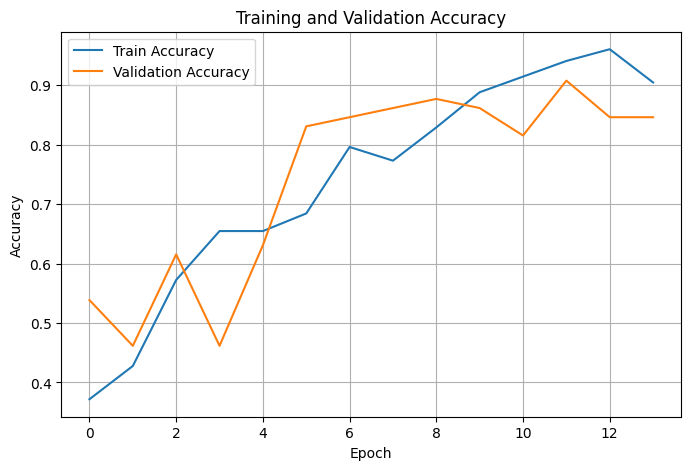

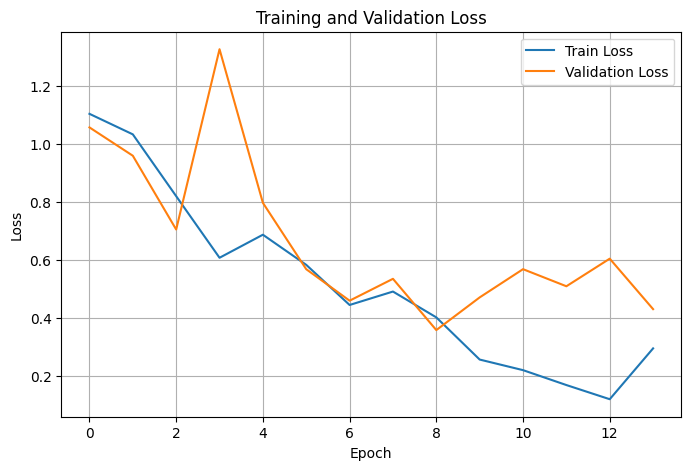

In [17]:
def plot_training_history(history):
    history_dict = history.history

    plt.figure(figsize=(8, 5))
    plt.plot(history_dict["accuracy"], label="Train Accuracy")
    plt.plot(history_dict["val_accuracy"], label="Validation Accuracy")
    plt.title("Training and Validation Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.grid(True)
    plt.show()

    plt.figure(figsize=(8, 5))
    plt.plot(history_dict["loss"], label="Train Loss")
    plt.plot(history_dict["val_loss"], label="Validation Loss")
    plt.title("Training and Validation Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True)
    plt.show()


plot_training_history(history)

**The model improved steadily during training, and the validation results stayed close to the training results. This shows that the model learned the three actions reasonably well without severe overfitting.**

In [18]:
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=1)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step - accuracy: 0.8310 - loss: 0.4293
Test Loss: 0.4498
Test Accuracy: 0.8182


In [19]:
y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)

print(classification_report(
    y_test,
    y_pred,
    target_names=[class_display_names[c] for c in selected_classes]
))

3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 580ms/step
              precision    recall  f1-score   support

      Biking       0.67      0.91      0.77        22
Tennis Swing       0.96      0.96      0.96        25
     Walking       0.91      0.53      0.67        19

    accuracy                           0.82        66
   macro avg       0.85      0.80      0.80        66
weighted avg       0.85      0.82      0.81        66



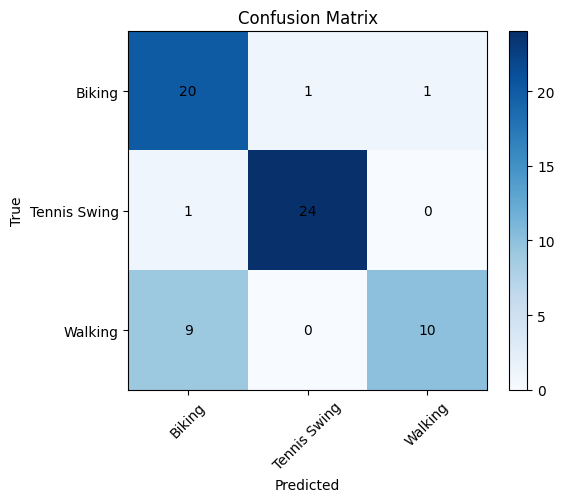

In [20]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
plt.imshow(cm, cmap="Blues")
plt.title("Confusion Matrix")
plt.colorbar()
plt.xticks(range(len(selected_classes)), [class_display_names[c] for c in selected_classes], rotation=45)
plt.yticks(range(len(selected_classes)), [class_display_names[c] for c in selected_classes])

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.show()

**The confusion matrix shows that Tennis Swing was classified most accurately, while Walking was the hardest class and was sometimes confused with Biking.**


In [21]:
final_model_path = f"/kaggle/working/{student_name}_action_recognition_model.keras"
model.save(final_model_path)

print("Best model saved at:", checkpoint_path)
print("Final model saved at:", final_model_path)

Best model saved at: /kaggle/working/Esraa_best_action_model.keras
Final model saved at: /kaggle/working/Esraa_action_recognition_model.keras


In [22]:
def predict_video_class(video_path, model):
    frames = frames_extraction(video_path, SEQUENCE_LENGTH, IMAGE_HEIGHT, IMAGE_WIDTH)

    if frames is None:
        return None, None

    input_video = np.expand_dims(frames, axis=0)
    prediction = model.predict(input_video, verbose=0)[0]

    predicted_label = int(np.argmax(prediction))
    predicted_class_name = selected_classes[predicted_label]
    confidence = float(np.max(prediction))

    return predicted_class_name, confidence


sample_test_video = paths_test[0]
predicted_class, confidence = predict_video_class(sample_test_video, model)

print("Video:", sample_test_video)
print("Predicted class:", predicted_class)
print("Confidence:", round(confidence, 4))

Video: /kaggle/input/datasets/pypiahmad/ucf-youtube-action-data-set/action_youtube_naudio/tennis_swing/v_tennis_09/v_tennis_09_03.avi
Predicted class: tennis_swing
Confidence: 0.9988


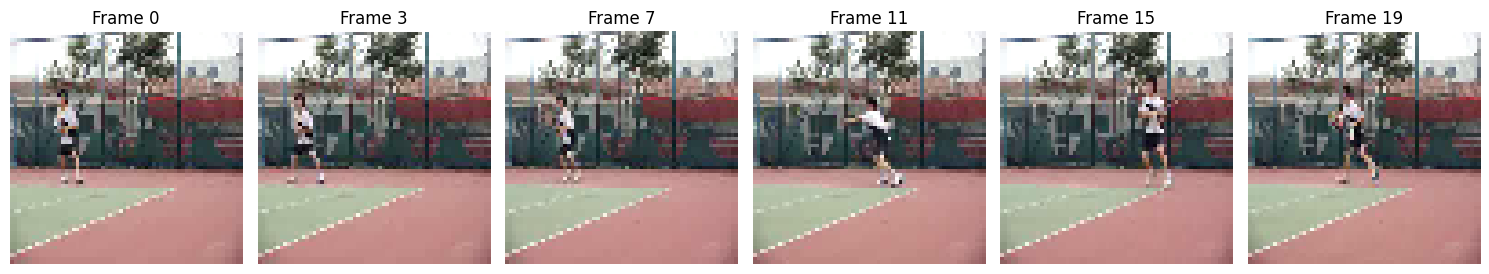

In [23]:
def show_video_frames(video_path, num_frames=6):
    frames = frames_extraction(video_path, SEQUENCE_LENGTH, IMAGE_HEIGHT, IMAGE_WIDTH)
    if frames is None:
        print("Could not extract frames.")
        return

    indices = np.linspace(0, len(frames) - 1, num_frames, dtype=int)

    plt.figure(figsize=(15, 3))
    for i, idx in enumerate(indices):
        plt.subplot(1, num_frames, i + 1)
        plt.imshow(frames[idx])
        plt.axis("off")
        plt.title(f"Frame {idx}")
    plt.tight_layout()
    plt.show()


show_video_frames(sample_test_video)

# Finally, the trained model is tested on 3 external videos to check how it performs on unseen examples.

In [32]:

from pathlib import Path

VIDEO_EXTENSIONS = {".avi", ".mp4", ".mov", ".mkv"}

external_video_files = []

for file_path in Path("/kaggle/input").rglob("*"):
    if file_path.is_file() and file_path.suffix.lower() in VIDEO_EXTENSIONS:
        # exclude training dataset videos
        if "action_youtube_naudio" not in str(file_path):
            external_video_files.append(str(file_path))

external_video_files = sorted(external_video_files)

print("External videos found:\n")
for i, video_path in enumerate(external_video_files, 1):
    print(f"{i}. {video_path}")

External videos found:

1. /kaggle/input/datasets/esraaldhayyan/action-video/14715698_3840_2160_60fps.mp4
2. /kaggle/input/datasets/esraaldhayyan/action-video/5740591-uhd_4096_2160_25fps.mp4
3. /kaggle/input/datasets/esraaldhayyan/action-video/5790177-hd_1920_1080_30fps.mp4


In [34]:
for video_path in external_video_files:
    predicted_class, confidence = predict_video_class(video_path, model)

    print("\n==============================")
    print("Video:", Path(video_path).name)
    print("Full path:", video_path)
    print("Predicted class:", predicted_class)
    print("Confidence:", round(confidence, 4) if confidence is not None else None)


Video: 14715698_3840_2160_60fps.mp4
Full path: /kaggle/input/datasets/esraaldhayyan/action-video/14715698_3840_2160_60fps.mp4
Predicted class: walking
Confidence: 0.5325

Video: 5740591-uhd_4096_2160_25fps.mp4
Full path: /kaggle/input/datasets/esraaldhayyan/action-video/5740591-uhd_4096_2160_25fps.mp4
Predicted class: biking
Confidence: 0.5099

Video: 5790177-hd_1920_1080_30fps.mp4
Full path: /kaggle/input/datasets/esraaldhayyan/action-video/5790177-hd_1920_1080_30fps.mp4
Predicted class: biking
Confidence: 0.7996


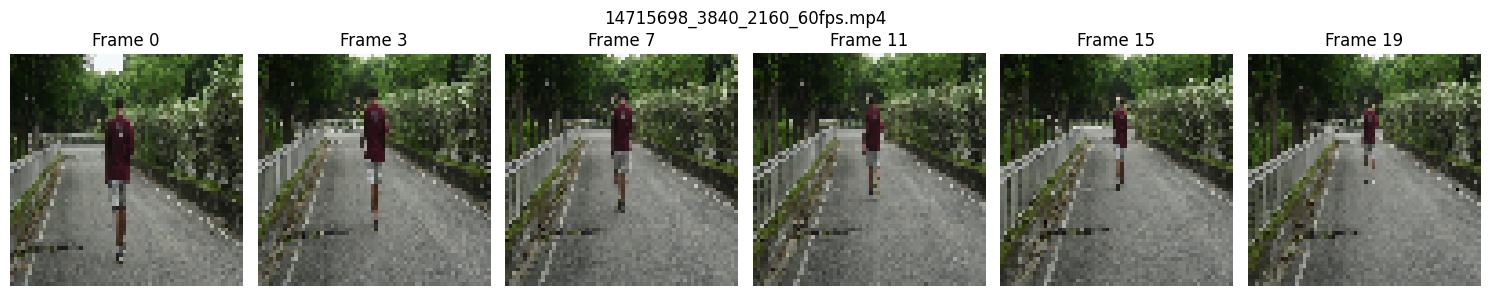

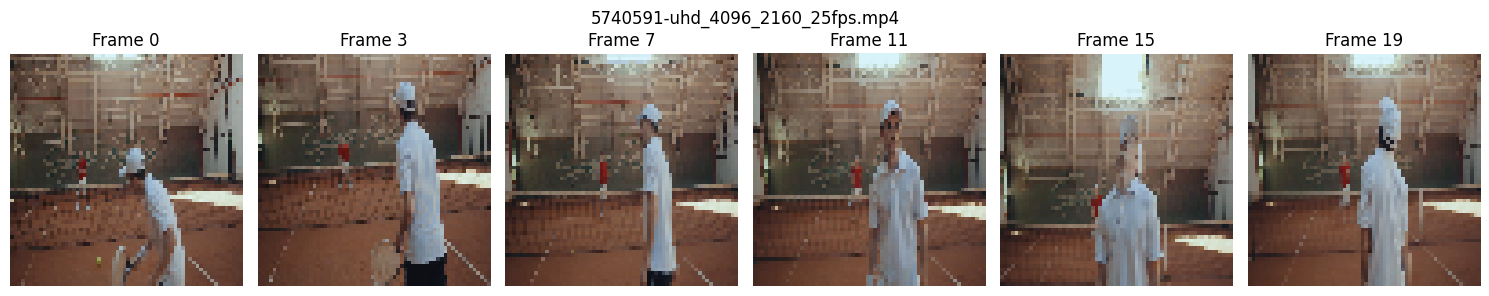

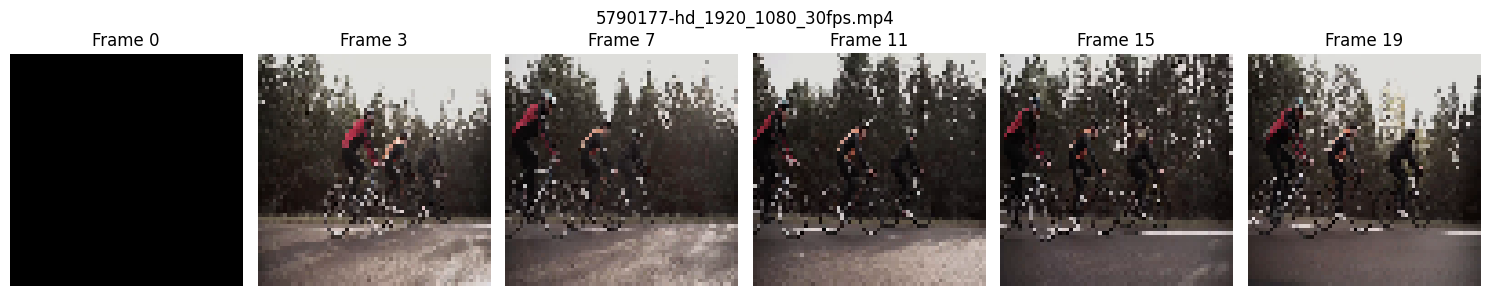

In [35]:
def show_video_frames(video_path, num_frames=6):
    frames = frames_extraction(video_path, SEQUENCE_LENGTH, IMAGE_HEIGHT, IMAGE_WIDTH)

    if frames is None:
        print("Could not extract frames from:", video_path)
        return

    indices = np.linspace(0, len(frames) - 1, num_frames, dtype=int)

    plt.figure(figsize=(15, 3))
    for i, idx in enumerate(indices):
        plt.subplot(1, num_frames, i + 1)
        plt.imshow(frames[idx])
        plt.axis("off")
        plt.title(f"Frame {idx}")
    plt.suptitle(Path(video_path).name)
    plt.tight_layout()
    plt.show()

for video_path in external_video_files:
    show_video_frames(video_path, num_frames=6)

In [36]:
import pandas as pd

results = []

for video_path in external_video_files:
    predicted_class, confidence = predict_video_class(video_path, model)

    results.append({
        "video_name": Path(video_path).name,
        "predicted_class": predicted_class,
        "confidence": round(confidence, 4) if confidence is not None else None
    })

results_df = pd.DataFrame(results)
results_df

,video_name,predicted_class,confidence
0,14715698_3840_2160_60fps.mp4,walking,0.5325
1,5740591-uhd_4096_2160_25fps.mp4,biking,0.5099
2,5790177-hd_1920_1080_30fps.mp4,biking,0.7996


In [37]:
student_name = "Esra Aldhayyan"
save_path = f"/kaggle/working/{student_name}_ucf11_model.h5"
model.save(save_path)
print(f"Model saved as {save_path}")

Model saved as /kaggle/working/Esra Aldhayyan_ucf11_model.h5
